# Return convergence — training and in-training eval return, per algorithm

Draws **two figures per algorithm** — the training return
`ray/tune/env_runners/episode_return_mean` and the in-training evaluation return
`ray/tune/evaluation/env_runners/episode_return_mean` — each overlaying that algorithm's four
GEN training configurations, so the held-out results
[`sps_eval_violins_evalcfg_cmp.ipynb`](sps_eval_violins_evalcfg_cmp.ipynb) reports can be read
against how far each run converged and against how far its training return had separated from
its eval return. The four variants differ only in which battery capacities they saw while
training:

| Variant | Training capacities |
|---|---|
| trained on 17 kWh | fixed 17 kWh |
| trained on 15 kWh | fixed 15 kWh |
| 5-way gen. | infra schedule cycling 10 / 12 / 15 / 17 / 20 kWh every 12 episodes |
| gen. distribution | `BatteryLinearWrapper` sampling 10-25 kWh per episode, holding out 12 / 16 / 22 |

For every snapshot the main RLlib TBX event file written by `tuner.fit()` under
`runs/train_*/models/**/events.out.tfevents.*` is parsed (the `ep_metrics/eval_trajectories/`
sub-runs live outside `models/` and are not matched by that glob) and three scalars are
extracted in a single pass: the two return curves above and the lifetime env-step counter
`ray/tune/env_runners/num_env_steps_sampled_lifetime`.

> **x-axis.** These snapshots predate the "use env steps as TensorBoard step axis" change
> (2026-07-15), so their event files are indexed by **training iteration** — and one iteration
> is a different amount of experience per algorithm: a PPO iteration advances the env-step
> counter by 3456 (12 episodes × 288 steps) over 583 iterations, a SAC one by 576 over 3488,
> and a DreamerV3 one by 288 — a single episode — over 7000. All three nevertheless cover
> essentially the same experience: PPO 2 018 304 steps / 7008 episodes, SAC and DreamerV3
> 2 016 000 / 7000. Plotting the raw TBX step is what made the old axis unreadable and
> incomparable across algorithms. The counter `num_env_steps_sampled_lifetime`, logged at every
> iteration by all three algorithms, is therefore read from the same event file and used as the
> x-axis instead, with a major tick every `X_TICK_ENV_STEPS` (250 000) environment steps. Set
> `X_AXIS = "episodes"` to relabel the same data in episodes (`env_steps / EPISODE_LENGTH`).

Parsing an event file is slow (the DreamerV3 logs are ~100 MB), so the extracted curves are
cached as small CSVs under `.tb_return_cache/` next to this notebook; delete that folder to
force a re-parse.

**Main input:** set `SOURCES` in the next cell.

In [6]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose return curves are plotted. Entries are grouped by "algo": every
# distinct algo gets its own pair of figures (training return, then in-training eval
# return), overlaying that algo's variants. Keys per entry:
#   path     snapshot dir (absolute, or relative to the repo root)
#   algo     algorithm class — one figure pair per distinct value, in first-seen order
#   variant  training configuration; shown in the legend, coloured via VARIANT_COLORS

SOURCES = [
    # --- PPO -------------------------------------------------------------------------
    {"path": "snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo_cp", "algo": "PPO", "variant": "trained on 17 kWh"},
    {"path": "snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo_cp", "algo": "PPO", "variant": "trained on 15 kWh"},
    {"path": "snapshots/20260714_235542_gen_battery_lin_so_all_ppo_v2_cp", "algo": "PPO", "variant": "5-way gen."},
    {"path": "snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo_cp", "algo": "PPO", "variant": "gen. distribution"},
    # --- SAC -------------------------------------------------------------------------
    {"path": "snapshots/20260714_161830_gen_battery_lin_so_only_17kW_sac_cp", "algo": "SAC", "variant": "trained on 17 kWh"},
    {"path": "snapshots/20260714_235241_gen_battery_lin_so_only_15kW_sac_cp", "algo": "SAC", "variant": "trained on 15 kWh"},
    {"path": "snapshots/20260714_162614_gen_battery_lin_so_all_sac_v2", "algo": "SAC", "variant": "5-way gen."},
    {"path": "snapshots/20260714_165943_gen_battery_lin_capacity_sampled_sac", "algo": "SAC", "variant": "gen. distribution"},
    # --- DreamerV3 -------------------------------------------------------------------
    {"path": "snapshots/20260714_225444_gen_battery_lin_so_only_17kW_dreamer", "algo": "DreamerV3", "variant": "trained on 17 kWh"},
    {"path": "snapshots/20260714_225342_gen_battery_lin_so_only_15kW_dreamer", "algo": "DreamerV3", "variant": "trained on 15 kWh"},
    {"path": "snapshots/20260714_225542_gen_battery_lin_so_all_dreamer_v2", "algo": "DreamerV3", "variant": "5-way gen."},
    {"path": "snapshots/20260714_225647_gen_battery_lin_capacity_sampled_dreamer", "algo": "DreamerV3", "variant": "gen. distribution"},
]

# Line colour per variant, shared across algorithms so all figures read the same way
# (deepened from the eval notebook's violin fills #75aef4 / #cc75f4 / #f1bd2d / #89f0cc).
VARIANT_COLORS = {
    "trained on 17 kWh": "#0d54c4",   # strong blue
    "trained on 15 kWh": "#a01ba8",   # strong magenta-purple
    "5-way gen.": "#e2660a",          # strong orange
    "gen. distribution": "#0a8f52",   # strong green
}

# The two RLlib return scalars, plus the lifetime env-step counter that supplies the
# x-axis. All three are pulled from the same event file in one pass.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"
ENV_STEPS_TAG = "ray/tune/env_runners/num_env_steps_sampled_lifetime"

# The figures drawn per algorithm: (curve column, y-axis label, filename tag).
FIGURE_KINDS = (
    ("train_return", "Mean training return", "train"),
    ("eval_return", "Mean evaluation return", "eval"),
)

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# x-axis unit: "env_steps" plots millions of environment steps, "episodes" plots
# env_steps / EPISODE_LENGTH. Major ticks land every X_TICK_ENV_STEPS / X_TICK_EPISODES.
X_AXIS = "episodes"
X_TICK_ENV_STEPS = 250_000
X_TICK_EPISODES = 1_000
EPISODE_LENGTH = 288

# Upper x-limit (in env steps) shared by every figure so the pairs line up; None takes the
# largest final env-step count across all loaded sources.
X_MAX_ENV_STEPS: float | None = None

# Return-axis major tick spacing, in return units.
Y_TICK_UNITS = 2.0

# Grid density: how many sub-intervals each major tick interval is split into by minor
# gridlines (1 = major gridlines only). Minor lines are drawn thinner and fainter.
X_MINOR_DIVISIONS = 2
Y_MINOR_DIVISIONS = 2

In [7]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util

# Bumped whenever the cached CSV's columns change, so a stale cache is re-parsed rather than read.
CACHE_SCHEMA = "v2-iter-envsteps-train-eval"


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"


# The main RLlib TBX log under models/ (largest event file wins; the per-episode
# eval_trajectories/ sub-runs live elsewhere and are not matched by this glob).
def _training_event_file(snapshot_dir: Path) -> Path:
    candidates = sorted(
        snapshot_dir.glob("runs/train_*/models/**/events.out.tfevents.*"),
        key=lambda path: path.stat().st_size, reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No training TBX event file under {snapshot_dir / 'runs/train_*/models'}")
    return candidates[0]


# Pulls both return curves and the lifetime env-step counter out of an event file in ONE
# pass (walking the file is the slow part), indexed by the TBX step — which for these
# snapshots is the training iteration, not the env step. Tags that log on different
# iterations (eval starts at evaluation_interval) simply leave NaNs in their column.
# Cached as a small CSV keyed by the event file's path + size + mtime, so an updated log
# re-parses. The path is resolved first: this tree is reachable both as /home/... and as
# /hkfs/home/..., and an unresolved key would miss the cache when the kernel reports the
# other form (VS Code's __vsc_ipynb_file__ and the cwd disagree here).
def _extract_curves(event_file: Path) -> pd.DataFrame:
    stat = event_file.stat()
    cache_key = hashlib.md5(f"{event_file.resolve()}|{stat.st_size}|{int(stat.st_mtime)}|{CACHE_SCHEMA}".encode()).hexdigest()
    cache_path = CACHE_DIR / f"{cache_key}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    wanted = {ENV_STEPS_TAG: "env_steps", TRAIN_METRIC: "train_return", EVAL_METRIC: "eval_return"}
    columns: dict[str, dict[int, float]] = {name: {} for name in wanted.values()}
    for event in EventFileLoader(str(event_file)).Load():
        for value in event.summary.value:
            column = wanted.get(value.tag)
            if column is None:
                continue
            # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
            scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
            columns[column][event.step] = scalar

    if not columns["env_steps"]:
        raise ValueError(f"Tag {ENV_STEPS_TAG!r} not found in {event_file} — no x-axis available")
    curve = pd.DataFrame(columns).rename_axis("iteration").sort_index().reset_index()
    CACHE_DIR.mkdir(exist_ok=True)
    curve.to_csv(cache_path, index=False)
    return curve


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float):
    if weight <= 0.0:
        return list(values)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return smoothed


ALGO_ORDER = list(dict.fromkeys(source["algo"] for source in SOURCES))
source_keys = [(source["algo"], source["variant"]) for source in SOURCES]
if len(source_keys) != len(set(source_keys)):
    raise ValueError(f"Every (algo, variant) pair must be unique; got {source_keys}")
uncoloured = sorted({source["variant"] for source in SOURCES} - VARIANT_COLORS.keys())
if uncoloured:
    raise KeyError(f"VARIANT_COLORS has no entry for {uncoloured}")
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}\nAlgorithms: {', '.join(ALGO_ORDER)}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/3_gen_bat_cap_v1/.tb_return_cache
Algorithms: PPO, SAC, DreamerV3


## Output naming

Everything saved here lands next to the notebook as
`<algo>_<kind>_return_<date>_<time>_out_<i>.<file format>` — e.g. `ppo_train_return_…` and
`ppo_eval_return_…` for the PPO pair: one timestamp per notebook run, `out_index` counting up
per saved artefact, so no run overwrites an earlier one.

In [8]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(prefix: str, file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{prefix}_{OUT_RUN_STAMP}_out_{out_index}.{file_format}"

## Load the return curves

Each snapshot's main training event file is located and its three scalars extracted (cached
after the first parse). The table lists, per (algo, variant): how many iterations the run
logged, how much experience that actually was in env steps and episodes, and for each of the
two return curves the number of logged points, the smoothed final value (what the end of the
plotted line shows) and the best raw value.

In [9]:
curves: dict[tuple[str, str], pd.DataFrame] = {}
summary_rows = []
for source in SOURCES:
    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    event_file = _training_event_file(snapshot_dir)
    curve = _extract_curves(event_file)
    curves[(source["algo"], source["variant"])] = curve

    final_env_step = int(curve["env_steps"].dropna().iloc[-1])
    row = {
        "algo": source["algo"],
        "variant": source["variant"],
        "iterations": int(curve["iteration"].max()),
        "env_steps": final_env_step,
        "episodes": final_env_step // EPISODE_LENGTH,
    }
    for column, _, kind in FIGURE_KINDS:
        series = curve[column].dropna()
        if series.empty:
            raise ValueError(f"No {column!r} points in {event_file}")
        row[f"{kind}_points"] = len(series)
        row[f"{kind}_final_smoothed"] = round(float(_tb_smooth(series.to_numpy(), SMOOTHING)[-1]), 3)
        row[f"{kind}_max_raw"] = round(float(series.max()), 3)
    summary_rows.append(row)
    print(f"{source['algo']:>10} / {source['variant']:<18}: {row['iterations']:>5} iters, {final_env_step:>9,} env steps"
          f"  ->  {event_file.relative_to(REPO_ROOT)}")

summary = pd.DataFrame(summary_rows).set_index(["algo", "variant"])

# Shared upper x-limit (env steps) so every figure spans the same range.
X_MAX = float(X_MAX_ENV_STEPS) if X_MAX_ENV_STEPS is not None else float(summary["env_steps"].max())
print(f"\nShared x-limit: {X_MAX:,.0f} env steps  ({X_MAX / EPISODE_LENGTH:,.0f} episodes)")
summary

       PPO / trained on 17 kWh :   583 iters, 2,018,304 env steps  ->  snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo_cp/runs/train_20260912_111730/models/gen_battery_lin_so_only_17kW_ppo/ray/ppo/ppo_seed42_20260913_181237/f0054_gen_battery_lin_so_only_17kW_ppo/events.out.tfevents.1789316003.haicn1701.localdomain
       PPO / trained on 15 kWh :   583 iters, 2,018,304 env steps  ->  snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo_cp/runs/train_20260912_111731/models/gen_battery_lin_so_only_15kW_ppo/ray/ppo/ppo_seed42_20260913_181237/f007c_gen_battery_lin_so_only_15kW_ppo/events.out.tfevents.1789316003.haicn1701.localdomain
       PPO / 5-way gen.        :   583 iters, 2,018,304 env steps  ->  snapshots/20260714_235542_gen_battery_lin_so_all_ppo_v2_cp/runs/train_20260912_111728/models/gen_battery_lin_so_all_ppo/ray/ppo/ppo_seed42_20260912_233558/f1654_gen_battery_lin_so_all_ppo/events.out.tfevents.1789249001.haicn1702.localdomain
       PPO / gen. distribution :  

iterations  env_steps  episodes  train_points  \
algo      variant                                                            
PPO       trained on 17 kWh         583    2018304      7008           583   
          trained on 15 kWh         583    2018304      7008           583   
          5-way gen.                583    2018304      7008           583   
          gen. distribution         583    2018304      7008           583   
SAC       trained on 17 kWh        3488    2016000      7000          3487   
          trained on 15 kWh        3488    2016000      7000          3487   
          5-way gen.               3488    2016000      7000          3487   
          gen. distribution        3488    2016000      7000          3487   
DreamerV3 trained on 17 kWh        7000    2016000      7000          7000   
          trained on 15 kWh        7000    2016000      7000          7000   
          5-way gen.               7000    2016000      7000          7000   
          gen. distribution        7000    2016000      7000          7000   

                             train_final_smoothed  train_max_raw  eval_points  \
algo      variant                                                               
PPO       trained on 17 kWh                12.497         16.182          574   
          trained on 15 kWh                12.115         15.368          574   
          5-way gen.                       10.488         17.527          574   
          gen. distribution                13.000         16.877          574   
SAC       trained on 17 kWh                14.678         19.265         3479   
          trained on 15 kWh                13.742         18.229         3479   
          5-way gen.                       14.253         21.438         3479   
          gen. distribution                14.138         20.572         3479   
DreamerV3 trained on 17 kWh                 8.468         12.394         6991   
          trained on 15 kWh                 7.415         10.624         6991   
          5-way gen.                        8.323         10.729         6991   
          gen. distribution                 8.706         10.584         6991   

                             eval_final_smoothed  eval_max_raw  
algo      variant                                               
PPO       trained on 17 kWh               13.933        15.377  
          trained on 15 kWh               13.468        14.709  
          5-way gen.                      13.438        15.721  
          gen. distribution               14.444        16.700  
SAC       trained on 17 kWh               15.304        17.637  
          trained on 15 kWh               14.248        16.479  
          5-way gen.                      13.715        15.898  
          gen. distribution               14.815        17.936  
DreamerV3 trained on 17 kWh                9.941        12.698  
          trained on 15 kWh                8.879        11.768  
          5-way gen.                       9.816        12.717  
          gen. distribution               10.148        11.773

## Convergence plots

Two figures per algorithm — training return, then in-training evaluation return — each
overlaying that algorithm's four variants in their `VARIANT_COLORS`, smoothed with
TensorBoard's debiased EWMA (`SMOOTHING = 0.99`); the raw curve is drawn faint behind each
smoothed line while `SHOW_RAW` is set.

Both axes are on fixed, readable scales: every figure shares the same x-limit with a major
tick every 250 000 environment steps (`X_TICK_ENV_STEPS`), and the return axis carries a major
tick every `Y_TICK_UNITS` = 2 return units. `X_MINOR_DIVISIONS` / `Y_MINOR_DIVISIONS` add a
minor gridline halfway between each pair of major ticks — a thinner, fainter grid at 125 000
steps and 1 return unit — so a variant's training and eval curves, and the same variant across
algorithms, can be read off against each other. The figures carry **no title** (thesis-ready)
and are saved as `<algo>_<kind>_return_<date>_<time>_out_<i>.pdf` next to this notebook.

PPO — train: saved ppo_train_return_20260921_155324_out_1.pdf


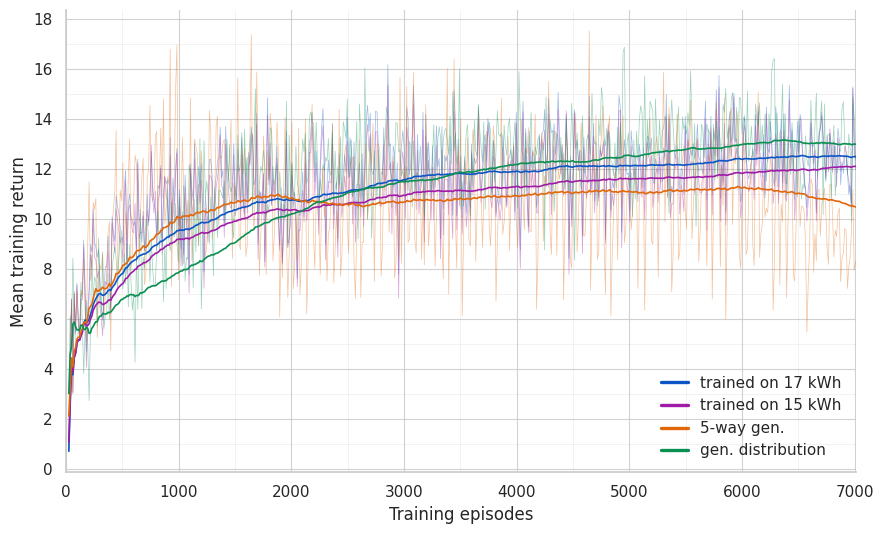

PPO — eval: saved ppo_eval_return_20260921_155324_out_2.pdf


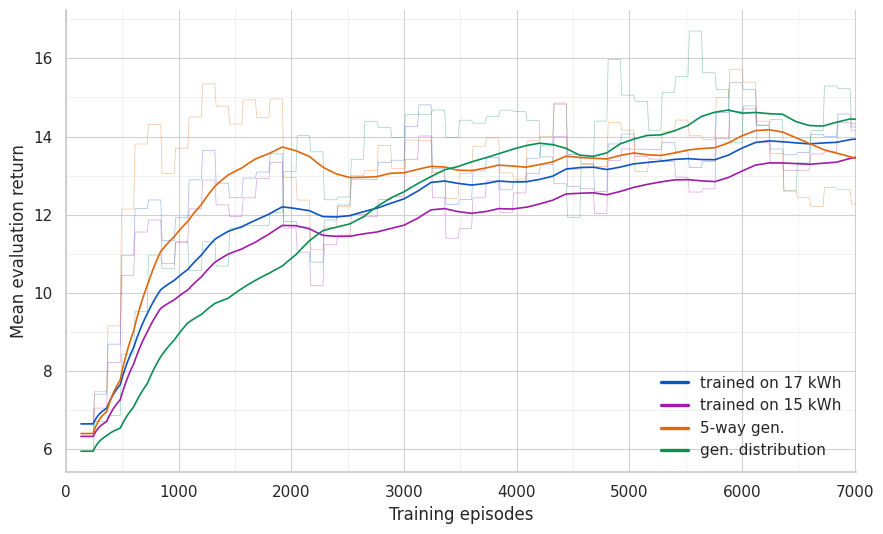

SAC — train: saved sac_train_return_20260921_155324_out_3.pdf


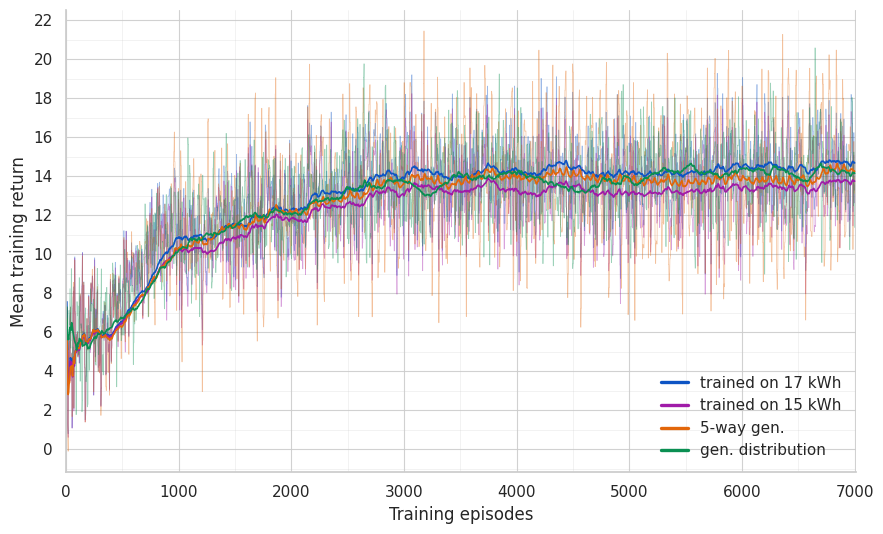

SAC — eval: saved sac_eval_return_20260921_155324_out_4.pdf


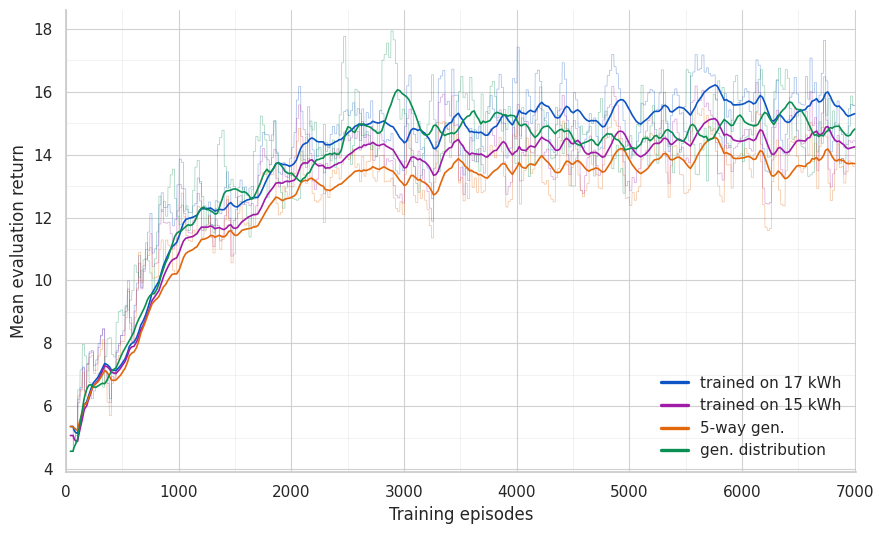

DreamerV3 — train: saved dreamerv3_train_return_20260921_155324_out_5.pdf


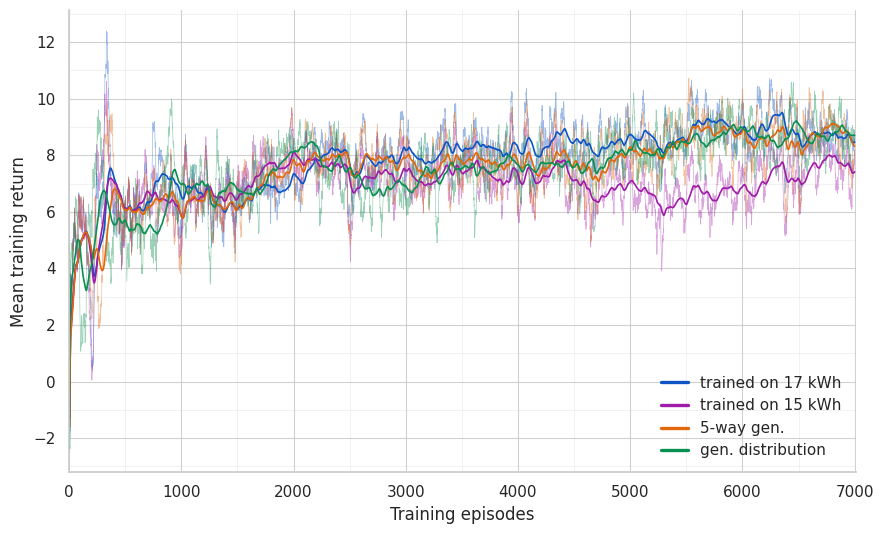

DreamerV3 — eval: saved dreamerv3_eval_return_20260921_155324_out_6.pdf


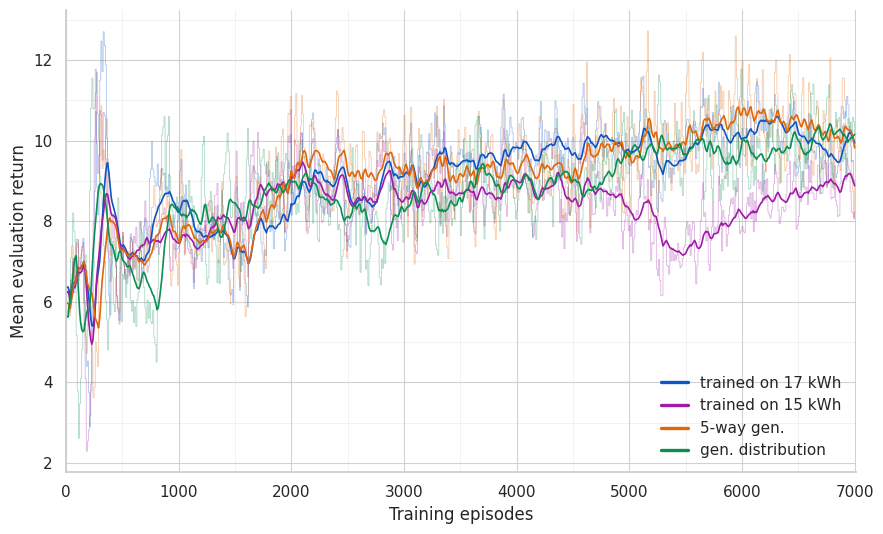

In [10]:
sns.set_theme(style="whitegrid", context="notebook")


# (divisor applied to env_steps, axis label, major-tick spacing, upper limit) for the
# configured X_AXIS. Everything is derived from the run's env-step counter, never from the
# TBX step, which for these snapshots is the training iteration.
def _x_axis_spec() -> tuple[float, str, float, float]:
    if X_AXIS == "env_steps":
        return 1e6, "Environment steps (millions)", X_TICK_ENV_STEPS / 1e6, X_MAX / 1e6
    if X_AXIS == "episodes":
        return float(EPISODE_LENGTH), "Training episodes", float(X_TICK_EPISODES), X_MAX / EPISODE_LENGTH
    raise ValueError(f"X_AXIS must be 'env_steps' or 'episodes'; got {X_AXIS!r}")


# Major ticks at the configured spacing on both axes, plus minor gridlines subdividing each
# major interval. AutoMinorLocator(n) splits an interval into n parts, so n = 1 leaves the
# minor grid empty — matplotlib rejects AutoMinorLocator(1), hence the guard.
def _apply_grid(ax) -> None:
    if X_MINOR_DIVISIONS > 1:
        ax.xaxis.set_minor_locator(AutoMinorLocator(X_MINOR_DIVISIONS))
    if Y_MINOR_DIVISIONS > 1:
        ax.yaxis.set_minor_locator(AutoMinorLocator(Y_MINOR_DIVISIONS))
    ax.grid(which="major", linewidth=0.8, alpha=0.9)
    ax.grid(which="minor", linewidth=0.4, alpha=0.45)


def plot_convergence(algo: str, column: str, y_label: str, kind: str) -> None:
    """One figure: every variant of `algo`, drawn from `column` of its extracted curve."""
    divisor, x_label, x_tick, x_max = _x_axis_spec()
    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    for source in (entry for entry in SOURCES if entry["algo"] == algo):
        frame = curves[(algo, source["variant"])][["env_steps", column]].dropna()
        x_values = frame["env_steps"] / divisor
        color = VARIANT_COLORS[source["variant"]]
        if SHOW_RAW:
            ax.plot(x_values, frame[column], color=color, alpha=0.40, linewidth=0.5, zorder=1)
        y_values = _tb_smooth(frame[column].to_numpy(), SMOOTHING)
        ax.plot(x_values, y_values, color=color, linewidth=1.2, label=source["variant"], zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(0.0, x_max)
    ax.xaxis.set_major_locator(MultipleLocator(x_tick))
    ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_UNITS))
    _apply_grid(ax)
    legend = ax.legend(title="", frameon=False, loc="lower right", handlelength=1.8)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path(f"{algo.lower()}_{kind}_return", "pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"{algo} — {kind}: saved {pdf_path.name}")
    plt.show()


for algo_name in ALGO_ORDER:
    for curve_column, axis_label, figure_kind in FIGURE_KINDS:
        plot_convergence(algo_name, curve_column, axis_label, figure_kind)